In [44]:
from checkers import MiniMaxGameBot, GameNode, RandomBot, GameState, new_board
import matplotlib.pyplot as plt
import numpy as np
from random import randint, seed

In [45]:
scores: list[list[float]] = []
number_of_games = 10
number_of_depth = 8
winners: list[list[int]] = [[0] * number_of_depth for _ in range(2)]

In [46]:
seeds = [randint(0, 100_000) for _ in range(number_of_games)]
for depth in range(1, number_of_depth + 1):
    score = []
    for game in range(number_of_games):
        bot1 = MiniMaxGameBot(GameNode(GameState(new_board()), 0), depth)  # b player
        random_bot = RandomBot(seeds[game]) # r player
        
        child_state_1 = bot1.minimax_move(True, None)
        score = [child_state_1.score]
        
        while True:
            child_state_2 = random_bot.random_move(child_state_1)
            
            if not child_state_2:
                break
            
            score.append(child_state_2.score)
            child_state_1 = bot1.minimax_move(False, child_state_2)
            
            if not child_state_1:
                break
            
            score.append(child_state_1.score)
        winners[0 if child_state_2 else 1][depth - 1] += 1
         # (True if player b wins, False if player r wins)
        
    scores.append(score)

Text(0.5, 1.0, 'Score during game')

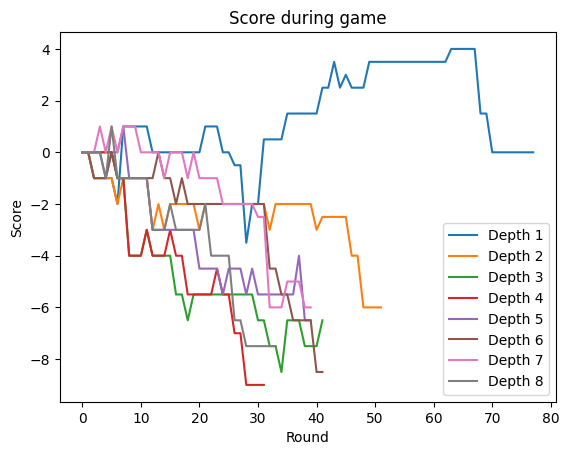

In [47]:
for i, score in enumerate(scores, start=1):
    plt.plot(score, label=f"Depth {i}")
plt.xlabel("Round")
plt.ylabel("Score")
plt.legend()
plt.title("Score during game")

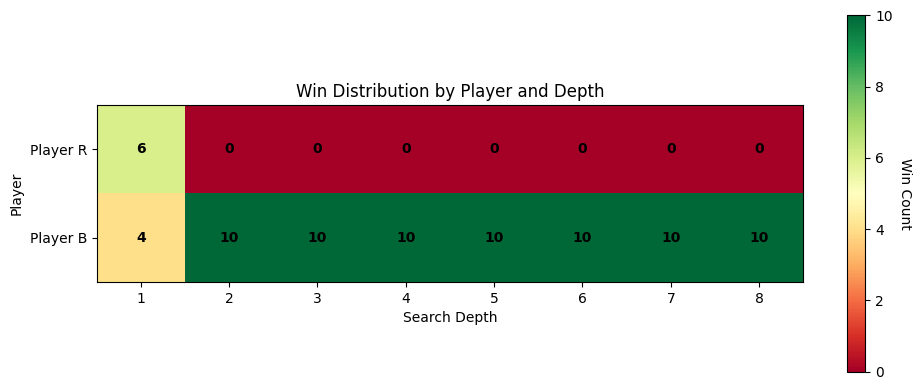

In [48]:
depths = [i for i in range(1, number_of_depth + 1)]
heatmap_data = np.array([winners[0], winners[1]])

fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(heatmap_data, cmap='RdYlGn')

cbar = ax.figure.colorbar(im, ax=ax)
cbar.ax.set_ylabel("Win Count", rotation=-90, va="bottom")

ax.set_xticks(np.arange(len(depths)))
ax.set_xticklabels(depths)
ax.set_yticks([0, 1])
ax.set_yticklabels(['Player R', 'Player B'])

plt.xlabel('Search Depth')
plt.ylabel('Player')
plt.title('Win Distribution by Player and Depth')

for i in range(2):
    for j in range(len(depths)):
        ax.text(j, i, heatmap_data[i, j], 
                ha="center", va="center", color="black", weight='bold')

plt.tight_layout()